In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
from mad.configs import sputnik_stages, sputnik
from mad.configs import EARTH_SETTINGS, MOON_SETTINGS
from mad.objs import Planet, PlanetConfig
from mad.objs import RocketConfig, RocketStage, RocketStageConfig, Rocket, SputnikConfig
from mad.guidances import NoGuidance, LEOInsertionGuidance
from mad.simulation import Simulation
from mad.utils.logger import SourceLogger
from mad.utils.plotters import plot_2D_planet_with_points
from mad.utils.objs_helpers import random_point_at_planet_surface, point_at_planet_surface_distance

logger = SourceLogger()

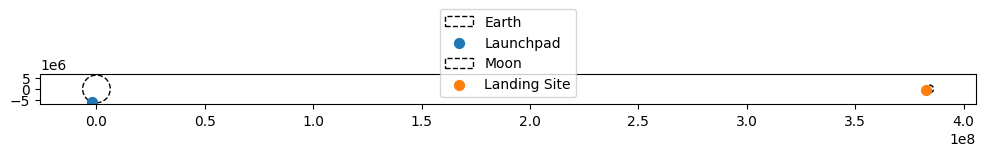

In [4]:
earth = Planet(PlanetConfig(**EARTH_SETTINGS))
launchpad = random_point_at_planet_surface(earth, name="Launchpad", altitude=10)
moon = Planet(PlanetConfig(**MOON_SETTINGS))
landing_site = random_point_at_planet_surface(moon, name="Landing Site", altitude=10)

fig, ax = plt.subplots(figsize=(10, 4))
plot_2D_planet_with_points(earth, [launchpad], ax)
plot_2D_planet_with_points(moon, [landing_site], ax)

fig.tight_layout(pad=1.2)


In [4]:
rocket_stages = [RocketStage(RocketStageConfig(**stage_cfg)) for stage_cfg in sputnik_stages]

# Complex Guidance Manager for the rocket to insert the payload into a LEO orbit
rocket_guidance = LEOInsertionGuidance(reference_planet=earth, 
                                        perigee_altitude_m = 200_000,
                                        apogee_altitude_m=400_000,
                                        min_turn_altitude_m=200,
                                        turn_end_altitude_m=180_000,)

sputnik_guidance = NoGuidance(reference_planet=earth, target=target)

payload_cfg = SputnikConfig(**sputnik, guidance = sputnik_guidance)

rocket_cfg = RocketConfig(stages=rocket_stages, 
                                     guidance=rocket_guidance, 
                                     payloads=[payload_cfg], 
                                     name="Semyorka")
semyorka = Rocket(position=launchpad.position.copy(), config=rocket_cfg, reference_planet=earth)

semyorka


Rocket Semyorka, active.
Stages: Bloc_BVGD, Bloc_A.
Available deltaV: 10459.25 m/s.
Guidance: GuidanceManager.
Payloads: Sputnik.

In [5]:
dt = 1.0
max_time = 15_000.

sim = Simulation(max_time=max_time, dt=dt)
sim.run(
    planet=earth,
    moving_objs=[semyorka],
)

df = sim.results

17:36:54 | INFO     | Simulation   | 0.00s - Starting simulation.
17:36:54 | INFO     | Guidance     | 7.00s - Switching to guidance law 1: CosinePitchProgram
17:36:54 | INFO     | Rocket       | 59.00s - Bloc_BVGD ran out of propellant at 59.00.
17:36:54 | INFO     | Rocket       | 59.00s - Semyorka - Bloc_BVGD separated at 59.00.
17:36:54 | INFO     | Simulation   | 59.00s - New objects spawned this step: ['Bloc_BVGD']
17:36:54 | INFO     | Guidance     | 224.00s - Switching to guidance law 2: OrbitalInsertion
17:36:54 | INFO     | Guidance     | 331.00s - Semyorka Orbit insertion achieved at altitude 210.6 km, v_horiz = 7927.0 m/s (target 7846.4 m/s).
17:36:54 | INFO     | Satellite    | 331.00s - Sputnik released into orbit -- Beep Beep!
17:36:54 | INFO     | Rocket       | 331.00s - Semyorka released payload Sputnik at 331.00.
17:36:54 | INFO     | Rocket       | 331.00s - Semyorka has released all payloads at 331.00. Stages deactivated.
17:36:54 | INFO     | Rocket       | 331.00

In [6]:
df["altitude_km"] = df["position"].apply(lambda pos: (np.linalg.norm(pos) - earth.radius) / 1e3)
df["energy_kJ"] = df["speed"].apply(lambda speed: 0.5 * speed**2 / 1e3)
df["gamma_deg"] = df["gamma"].apply(lambda g: np.degrees(g) if g is not None else None)
df = df.sort_values(by=["name", "time"])

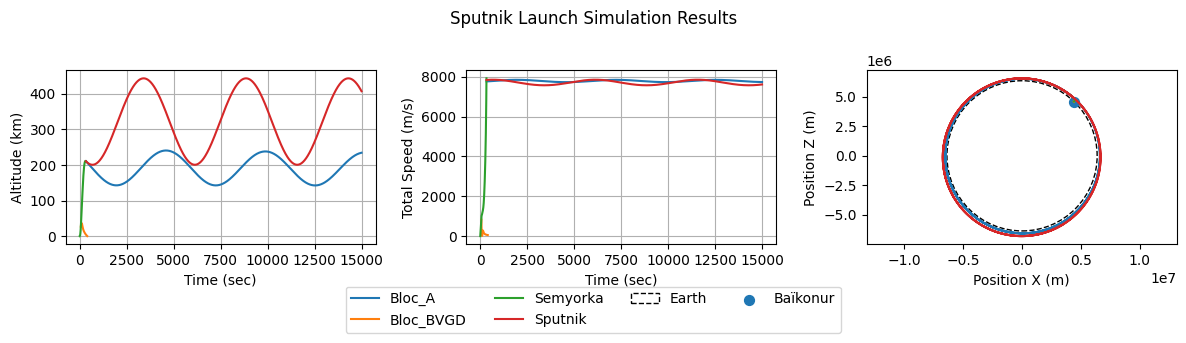

In [7]:
fig, ax = plt.subplots(ncols=3, nrows=1, figsize=(12, 3))
ax = ax.ravel()

sns.lineplot(data=df, x="time", y="altitude_km", hue="name", ax=ax[0])
sns.lineplot(data=df, x="time", y="speed", hue="name", ax=ax[1])
sns.lineplot(data=df, x="posx", y="posz", hue="name", ax=ax[2], sort=False, errorbar=None)

ax[0].set_xlabel("Time (sec)")
ax[0].set_ylabel("Altitude (km)")

ax[1].set_xlabel("Time (sec)")
ax[1].set_ylabel("Total Speed (m/s)")

plot_2D_planet_with_points(earth, points = [launchpad], ax=ax[2], display="planet")
ax[2].set_xlabel("Position X (m)")
ax[2].set_ylabel("Position Z (m)")
ax[2].set_aspect("equal", adjustable="datalim")

for a in ax:
    a.grid()
    a.legend()
    handles, labels = a.get_legend_handles_labels()
    a.legend().remove()

fig.suptitle("Sputnik Launch Simulation Results")
fig.legend(handles, labels, loc="lower center", ncol=4, bbox_to_anchor=(0.5, -0.12))
fig.tight_layout(pad=1.2)
